# Módulo 5 · Selección automática de orden: AutoReg y ar_select_order

Curso: **Series Temporales con R y Python** (Frogames Formación).

Notebook de acompañamiento de la lección `05-modelos-ar/03-seleccion-automatica-de-orden-autoreg` — ábrelo mientras lees la lección y ejecuta cada celda tú mismo.

Trabajamos con `uspopulation.csv` (en esta misma carpeta): población mensual estimada de EE.UU. en miles de personas, enero de 2011 a diciembre de 2018 (96 observaciones).

**Nota de migración — la más importante del módulo**: `statsmodels.tsa.ar_model.AR` fue **eliminado por completo** de `statsmodels`. Su reemplazo es `AutoReg` + `ar_select_order`, con cambios de firma notables:

- Antes: un único objeto `AR(serie)` que se reutilizaba llamando `.fit(maxlag=N)` con distinto `N` cada vez.
- Ahora: `AutoReg(serie, lags=N)` crea un modelo *nuevo* por cada conjunto de lags — no se reutiliza el objeto.
- Antes: `.fit(ic='bic')` sobre `AR` elegía el orden automáticamente. Ahora esa selección es una función aparte, `ar_select_order(serie, maxlag=8, ic='bic')`, que devuelve los lags elegidos (no necesariamente consecutivos) en `.ar_lags`.
- Antes: `.k_ar` daba el número de lags. Ahora es `.ar_lags` (una lista, no un entero).
- El indexado posicional `serie[i]` sobre una Serie con índice de fechas ya no funciona — hace falta `.iloc[i]`.

In [1]:
import matplotlib.pyplot as plt

# Estilo oscuro opcional, para que los gráficos combinen con el tema del curso.
# No afecta a ningún resultado numérico -- puedes omitir esta celda sin problema.
plt.rcParams.update({
    "figure.facecolor": "#0d0d10", "axes.facecolor": "#0d0d10",
    "axes.edgecolor": "#a8a8b3", "axes.labelcolor": "#e1e1e6",
    "xtick.color": "#a8a8b3", "ytick.color": "#a8a8b3",
    "text.color": "#e1e1e6", "grid.color": "#232326",
    "font.size": 11,
})

## Carga

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("uspopulation.csv", index_col="DATE", parse_dates=True)
df.index.freq = "MS"
df.head()

,PopEst
DATE,
2011-01-01,311037
2011-02-01,311189
2011-03-01,311351
2011-04-01,311522
2011-05-01,311699


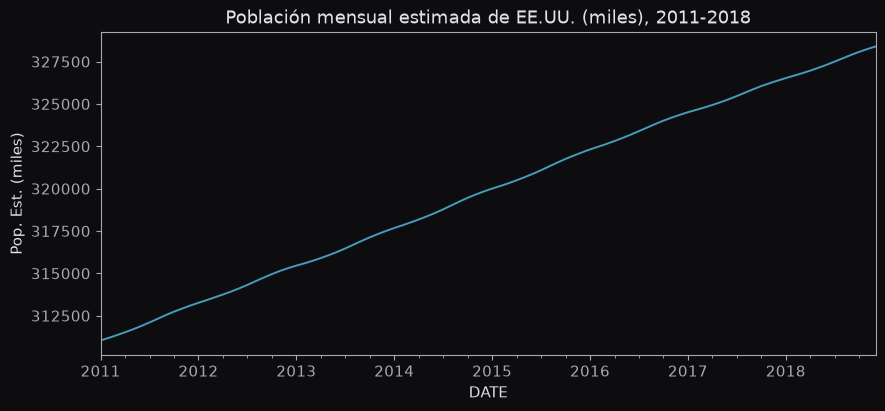

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.2))
df["PopEst"].plot(ax=ax, color="#449cb9", linewidth=1.4)
ax.set_title("Población mensual estimada de EE.UU. (miles), 2011-2018")
ax.set_ylabel("Pop. Est. (miles)")
plt.show()

## Train / test split

In [4]:
print("total filas:", len(df))
train = df.iloc[:84]
test = df.iloc[84:]
print(f"train: {len(train)} · test: {len(test)}")

total filas: 96
train: 84 · test: 12


## AR(1) con `AutoReg`

`AutoReg(serie, lags=1)` sustituye a `AR(serie).fit(maxlag=1)`. `.ar_lags` sustituye a `.k_ar`.

In [5]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.ar_model import AutoReg

AR1fit = AutoReg(train["PopEst"], lags=1).fit()
print(f"Lags: {AR1fit.ar_lags}")
print(f"Coeficientes:\n{AR1fit.params}")

Lags: [1]
Coeficientes:
const        284.913797
PopEst.L1      0.999686
dtype: float64


In [6]:
start = len(train)
end = len(train) + len(test) - 1
predictions1 = AR1fit.predict(start=start, end=end, dynamic=False).rename("AR(1) Predictions")
predictions1

2018-01-01    326560.403377
2018-02-01    326742.749463
2018-03-01    326925.038278
2018-04-01    327107.269838
2018-05-01    327289.444162
2018-06-01    327471.561268
2018-07-01    327653.621173
2018-08-01    327835.623896
2018-09-01    328017.569455
2018-10-01    328199.457868
2018-11-01    328381.289152
2018-12-01    328563.063326
Freq: MS, Name: AR(1) Predictions, dtype: float64

## Comparando predicción con valor real

**Nota de migración**: `predictions1[i]` y `test['PopEst'][i]` (indexado posicional sobre una Serie con índice de fechas) ya no funcionan en pandas moderno — hace falta `.iloc[i]`.

In [7]:
for i in range(len(predictions1)):
    pred = predictions1.iloc[i]
    real = test["PopEst"].iloc[i]
    print(f"predicted={pred:<14.6f}, expected={real}")

predicted=326560.403377 , expected=326527
predicted=326742.749463 , expected=326669
predicted=326925.038278 , expected=326812
predicted=327107.269838 , expected=326968
predicted=327289.444162 , expected=327134
predicted=327471.561268 , expected=327312
predicted=327653.621173 , expected=327502
predicted=327835.623896 , expected=327698
predicted=328017.569455 , expected=327893
predicted=328199.457868 , expected=328077
predicted=328381.289152 , expected=328241
predicted=328563.063326 , expected=328393


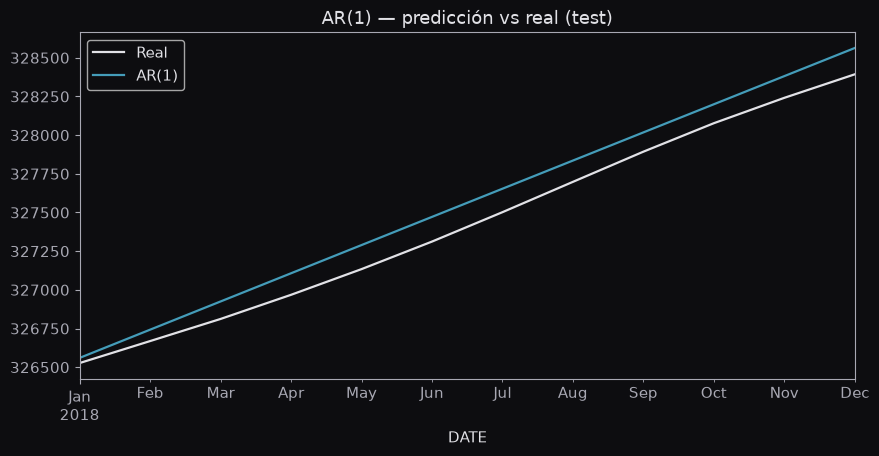

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
test["PopEst"].plot(ax=ax, color="#e1e1e6", linewidth=1.6, label="Real")
predictions1.plot(ax=ax, color="#449cb9", linewidth=1.6, label="AR(1)")
ax.set_title("AR(1) — predicción vs real (test)")
ax.legend()
plt.show()

## AR(2) con `AutoReg`

In [9]:
AR2fit = AutoReg(train["PopEst"], lags=2).fit()
print(f"Lags: {AR2fit.ar_lags}")
print(f"Coeficientes:\n{AR2fit.params}")

predictions2 = AR2fit.predict(start=start, end=end, dynamic=False).rename("AR(2) Predictions")

Lags: [1, 2]
Coeficientes:
const        137.368305
PopEst.L1      1.853490
PopEst.L2     -0.853836
dtype: float64


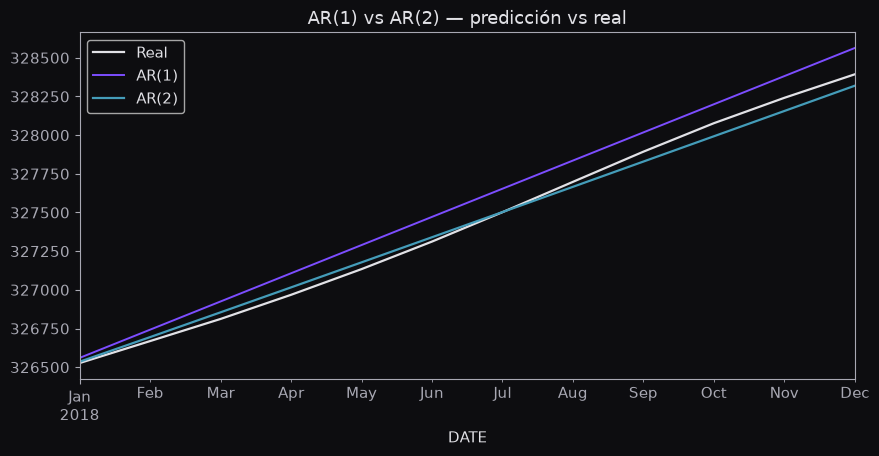

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
test["PopEst"].plot(ax=ax, color="#e1e1e6", linewidth=1.6, label="Real")
predictions1.plot(ax=ax, color="#7c4dff", linewidth=1.4, label="AR(1)")
predictions2.plot(ax=ax, color="#449cb9", linewidth=1.6, label="AR(2)")
ax.set_title("AR(1) vs AR(2) — predicción vs real")
ax.legend()
plt.show()

## Selección automática de orden con `ar_select_order`

Le pedimos a `statsmodels` que pruebe hasta 8 lags y se quede con el conjunto que minimiza el BIC — el equivalente moderno de `AR(...).fit(ic='bic')`.

In [11]:
from statsmodels.tsa.ar_model import ar_select_order

selection = ar_select_order(train["PopEst"], maxlag=8, ic="bic")
print("Orden seleccionado (lags):", selection.ar_lags)

ARfit = AutoReg(train["PopEst"], lags=selection.ar_lags).fit()
print(f"Lags usados: {ARfit.ar_lags}")
print(f"Coeficientes:\n{ARfit.params}")

Orden seleccionado (lags): [1, 2, 3, 4, 5, 6, 7, 8]
Lags usados: [1, 2, 3, 4, 5, 6, 7, 8]
Coeficientes:
const        82.309677
PopEst.L1     2.437997
PopEst.L2    -2.302100
PopEst.L3     1.565427
PopEst.L4    -1.431211
PopEst.L5     1.125022
PopEst.L6    -0.919494
PopEst.L7     0.963694
PopEst.L8    -0.439511
dtype: float64


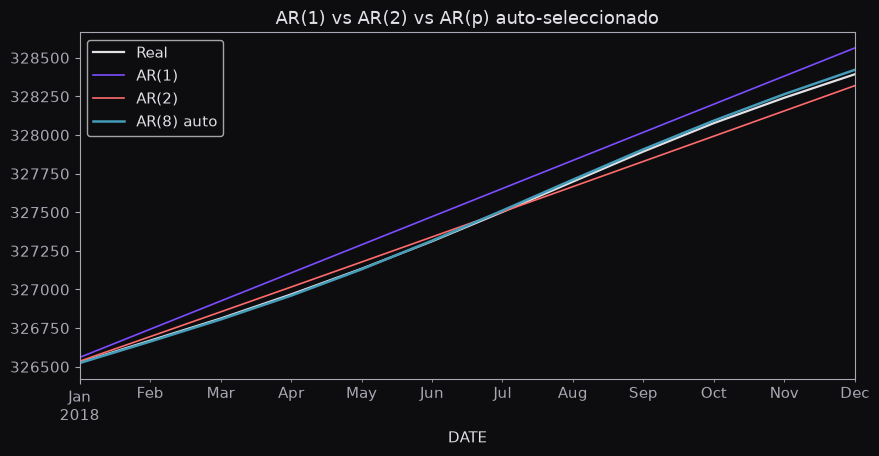

In [12]:
predictions8 = ARfit.predict(start=start, end=end, dynamic=False).rename("AR(p) seleccionado Predictions")

fig, ax = plt.subplots(figsize=(10, 4.5))
test["PopEst"].plot(ax=ax, color="#e1e1e6", linewidth=1.6, label="Real")
predictions1.plot(ax=ax, color="#7c4dff", linewidth=1.2, label="AR(1)")
predictions2.plot(ax=ax, color="#ff6b6b", linewidth=1.2, label="AR(2)")
predictions8.plot(ax=ax, color="#449cb9", linewidth=1.8, label=f"AR({len(selection.ar_lags)}) auto")
ax.set_title("AR(1) vs AR(2) vs AR(p) auto-seleccionado")
ax.legend()
plt.show()

## Evaluando con MSE y AIC

In [13]:
from sklearn.metrics import mean_squared_error

labels = ["AR(1)", "AR(2)", f"AR({len(selection.ar_lags)}) auto"]
preds = [predictions1, predictions2, predictions8]

for label, pred in zip(labels, preds):
    error = mean_squared_error(test["PopEst"], pred)
    print(f"{label} Error (MSE): {error:.6f}")

AR(1) Error (MSE): 17449.714233
AR(2) Error (MSE): 2713.258534
AR(8) auto Error (MSE): 186.974372


In [14]:
models = [AR1fit, AR2fit, ARfit]
for label, mod in zip(labels, models):
    print(f"{label} AIC: {mod.aic:.6f}")

AR(1) AIC: 767.637809
AR(2) AIC: 649.209485
AR(8) auto AIC: 488.353053


## Pronóstico a 12 meses, reentrenando con toda la serie

In [15]:
final_selection = ar_select_order(df["PopEst"], maxlag=8, ic="bic")
print("Orden seleccionado sobre la serie completa:", final_selection.ar_lags)

final_model = AutoReg(df["PopEst"], lags=final_selection.ar_lags).fit()
fcast = final_model.predict(start=len(df), end=len(df) + 11, dynamic=False).rename("Forecast")
fcast

Orden seleccionado sobre la serie completa: [1, 2, 3, 4, 5, 6, 7, 8]


2019-01-01    328537.134658
2019-02-01    328675.917691
2019-03-01    328818.863492
2019-04-01    328973.057123
2019-05-01    329142.516131
2019-06-01    329325.479787
2019-07-01    329516.233876
2019-08-01    329709.938453
2019-09-01    329899.389698
2019-10-01    330077.704951
2019-11-01    330242.358988
2019-12-01    330394.543678
Freq: MS, Name: Forecast, dtype: float64

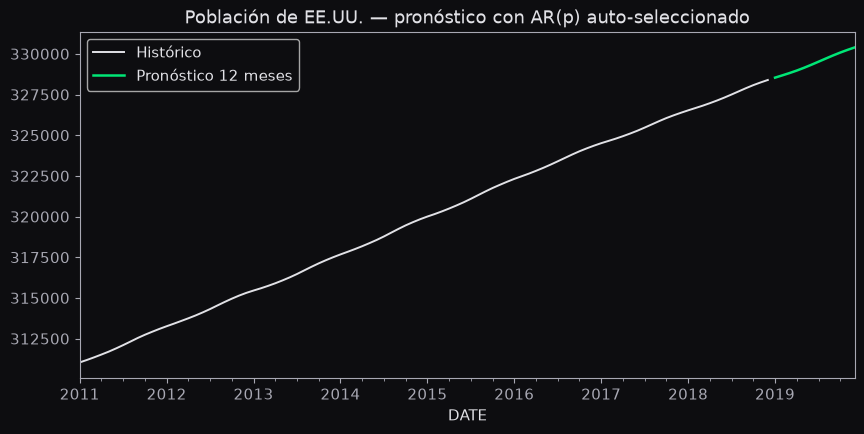

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
df["PopEst"].plot(ax=ax, color="#e1e1e6", linewidth=1.4, label="Histórico")
fcast.plot(ax=ax, color="#00e676", linewidth=1.8, label="Pronóstico 12 meses")
ax.set_title("Población de EE.UU. — pronóstico con AR(p) auto-seleccionado")
ax.legend()
plt.show()

**Entregable**: reproduce estas celdas y, en tus notas, contesta: el orden auto-seleccionado usa los 8 lags disponibles (no descarta ninguno). El MSE de este modelo (≈187) es enormemente menor que el de AR(1) (≈17.450) o AR(2) (≈2.713). ¿Por qué tiene sentido que una serie tan suave y con tendencia tan marcada como la población necesite varios lags para predecir bien, en vez de bastarle con el valor inmediatamente anterior?

La contrapartida en R de esta misma idea —selección automática de orden AR por AIC, con `ar()` base— está en `05-modelos-ar/R/03_ar_lynx.R`, sobre el dataset `lynx`.